In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt 

# cloelite imports
from cloelite.cosmology.camb_cosmology import CAMBBackground
from cloelite.cosmology.jax_cosmology import JAXBackground

# Validation benchmark is astropy
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import camb

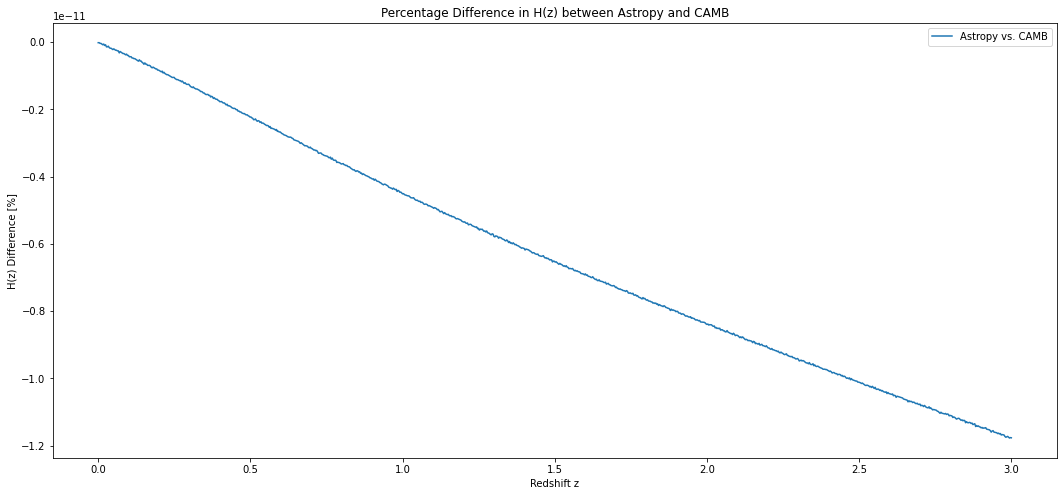

In [11]:
# Cosmology parameters
H0 =  67.7
h = H0/100.
sigma8 = 0.8277
Omm = 0.3097
Omc = 0.26067408193677466
Omb = 0.04902591806322532
w = -1
wa = 0

# Astropy
Tcmb = 2.7255
Neff = 0.0#3.046
YHe = 0.2454 

# z-array
z = np.linspace(0, 3, 1000)

astropy_instance = FlatLambdaCDM(H0=H0,Om0=Omm,Ob0=Omb,Tcmb0=Tcmb,Neff=Neff,m_nu=[0,0,0.0]*u.eV)
H_z_astropy = astropy_instance.H(z).to(u.km/u.s/u.Mpc).value

camb_instance = CAMBBackground(H0=H0,Omc=Omc,Omb=Omb, w=w, wa=wa, sigma8=sigma8, Omk = 0.0, ns = 0.96, gamma_MG = 0.545)
H_z_camb = camb_instance.hubble_parameter(z, units='km/s/Mpc')

jax_instance = JAXBackground(H0=H0,Omc=Omc,Omb=Omb, w=w, wa=wa, sigma8=sigma8, Omk = 0.0, ns = 0.96, gamma_MG = 0.545)
H_z_jax = jax_instance.hubble_parameter(z)

plt.figure(figsize = (18,8))
plt.plot(z, 100*(H_z_camb- H_z_astropy)/H_z_astropy, label = 'Astropy vs. CAMB')
#plt.plot(z, 100*(H_z_jax- H_z_astropy)/H_z_astropy, label = 'Astropy vs. JAX')
plt.ylabel('H(z) Difference [%]')
plt.title('Percentage Difference in H(z) between Astropy and CAMB')
plt.xlabel('Redshift z')
plt.legend()

#Differences are due to neutrinos